# Model Comparison: Prophet vs XGBoost vs LSTM vs Ensemble

**Purpose:** Dissertation evidence for the ERIS forecasting module.

This notebook evaluates four forecasting approaches on a 30-day holdout set drawn from
the seeded ERIS database.

- **Prophet** — Facebook's additive decomposition model with Indian holiday regressors.
- **XGBoost** — Gradient-boosted trees on lag/rolling/cyclical features.
- **LSTM** — PyTorch sequence model (results shown only when PyTorch is available).
- **Ensemble** — Inverse-error-weighted combination of the three individual models.

All models are imported directly from `app.ml.forecasting` so this notebook always
reflects the live production code and cannot silently drift.

**Database path** is resolved by walking up from CWD until a directory containing both
`backend/` and `research/` is found. Override with `ERIS_DB_PATH` env var for CI.

---

## MAPE Investigation — why the previous notebook reported 127–250%

The original `gen_notebook.py` queried individual sale-item rows and called
`df.groupby('date')['y'].sum()` in pandas **after** fetching per-row data. Because the
`sales` table has many rows per calendar day (one per product sold), the “last 30 rows”
holdout contained 30 individual transaction rows—all timestamped on the same final
date—with per-item quantities of 1–26 units.

The correct fix is `DATE(sale_date)` in the SQL `GROUP BY`, yielding genuine
one-row-per-calendar-day totals (389–3012 units/day).

**Verified from actual DB query:**

| | Outlet 1 | Outlet 2 |
|---|---|---|
| Unique days in DB | 366 | 366 |
| Holdout min y | 419 | 456 |
| Holdout max y | 3012 | 1861 |
| Holdout zero days | 0 | 0 |
| Naive (train-mean) MAPE | 33.1% | 28.1% |

The 127–250% figures were a **data pipeline bug**, not a model fit problem.

In [1]:
# Cell 1: Environment bootstrap
# Must run BEFORE any 'from app.*' import because app.core.config.Settings
# validates DATABASE_URL at import time.

import sys
import os
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Step 1: Locate project root by walking up from CWD ────────────────────────
def _find_project_root() -> Path:
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / 'backend').is_dir() and (p / 'research').is_dir():
            return p
    raise FileNotFoundError(
        f'Cannot locate project root from CWD={Path.cwd()}. '
        'Set ERIS_DB_PATH env var to the absolute path of eris_dev.db.'
    )

if 'ERIS_DB_PATH' in os.environ:
    DB_PATH      = Path(os.environ['ERIS_DB_PATH'])
    PROJECT_ROOT = DB_PATH.parents[1]
    BACKEND_DIR  = DB_PATH.parent
else:
    PROJECT_ROOT = _find_project_root()
    BACKEND_DIR  = PROJECT_ROOT / 'backend'
    DB_PATH      = BACKEND_DIR / 'eris_dev.db'

print(f'Project root : {PROJECT_ROOT}')
print(f'Backend dir  : {BACKEND_DIR}')
print(f'Database     : {DB_PATH}')
print(f'DB exists    : {DB_PATH.exists()}, size: {DB_PATH.stat().st_size:,} bytes')

# ── Step 2: Set DATABASE_URL BEFORE importing any app.* module ────────────────
# app.core.config.Settings validates DATABASE_URL at module import time.
# The SQLite dev DB is at backend/eris_dev.db; we tell Settings about it so
# the import chain (prophet_forecaster -> external_factors_service -> database)
# does not crash with a missing-env-var error.
# The notebook itself never opens this SQLite via the async ORM — it queries
# directly with sqlite3. This just satisfies the config validator.
if 'DATABASE_URL' not in os.environ or not os.environ['DATABASE_URL']:
    os.environ['DATABASE_URL'] = f'sqlite+aiosqlite:///{DB_PATH}'
    print(f'Set DATABASE_URL = {os.environ["DATABASE_URL"]}')
else:
    print(f'DATABASE_URL already set: {os.environ["DATABASE_URL"][:60]}...')

# ── Step 3: Add backend to sys.path ───────────────────────────────────────────
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))
print(f'sys.path[0]  : {sys.path[0]}')

Project root : C:\Users\littl\Downloads\eris_project
Backend dir  : C:\Users\littl\Downloads\eris_project\backend
Database     : C:\Users\littl\Downloads\eris_project\backend\eris_dev.db
DB exists    : True, size: 107,061,248 bytes
Set DATABASE_URL = sqlite+aiosqlite:///C:\Users\littl\Downloads\eris_project\backend\eris_dev.db
sys.path[0]  : C:\Users\littl\Downloads\eris_project\backend


In [2]:
# Cell 2: Import production ML classes
# DATABASE_URL is now set, so the import chain will not raise ValidationError.

from app.ml.forecasting.prophet_forecaster import ProphetForecaster, _check_prophet
from app.ml.forecasting.xgboost_forecaster import XGBoostForecaster
from app.ml.forecasting.lstm_forecaster import LSTMForecaster, TORCH_AVAILABLE
from app.ml.forecasting.ensemble import EnsembleForecaster

print('ProphetForecaster:  imported OK')
print('XGBoostForecaster:  imported OK')
print('LSTMForecaster:     imported OK')
print('EnsembleForecaster: imported OK')
print(f'Prophet available:  {_check_prophet()}')
print(f'PyTorch available:  {TORCH_AVAILABLE}')

ProphetForecaster:  imported OK
XGBoostForecaster:  imported OK
LSTMForecaster:     imported OK
EnsembleForecaster: imported OK


ERROR:prophet.plot:Importing plotly failed. Interactive plots will not work.


Prophet available:  True
PyTorch available:  False


In [3]:
# Cell 3: Load and inspect daily sales data
# DATE(sale_date) in GROUP BY produces one row per calendar day.

OUTLET_IDS   = [1, 2]
HOLDOUT_DAYS = 30

def load_outlet_data(outlet_id: int, db_path: Path) -> pd.DataFrame:
    conn = sqlite3.connect(str(db_path))
    df = pd.read_sql_query(
        """
        SELECT DATE(s.sale_date) AS ds,
               SUM(si.quantity)  AS y
        FROM   sales     s
        JOIN   sale_items si ON s.id = si.sale_id
        WHERE  s.outlet_id = ?
        GROUP  BY DATE(s.sale_date)
        ORDER  BY DATE(s.sale_date)
        """,
        conn, params=(outlet_id,)
    )
    conn.close()
    df['ds'] = pd.to_datetime(df['ds'])
    df['y']  = df['y'].astype(float)
    return df

print('Loading data...')
outlet_data = {}
for oid in OUTLET_IDS:
    df = load_outlet_data(oid, DB_PATH)
    outlet_data[oid] = df
    holdout = df.iloc[-HOLDOUT_DAYS:]
    print(f'\n  Outlet {oid}: {len(df)} unique days '
          f'({df["ds"].min().date()} to {df["ds"].max().date()})')
    print(f'  Full dataset  min={df["y"].min():.0f}  max={df["y"].max():.0f}  '
          f'mean={df["y"].mean():.1f}')
    print(f'  Holdout 30d   min={holdout["y"].min():.0f}  max={holdout["y"].max():.0f}  '
          f'mean={holdout["y"].mean():.1f}  zero_days={(holdout["y"]==0).sum()}')

Loading data...



  Outlet 1: 366 unique days (2025-09-01 to 2026-09-01)
  Full dataset  min=389  max=3012  mean=766.0
  Holdout 30d   min=419  max=3012  mean=771.4  zero_days=0



  Outlet 2: 366 unique days (2025-09-01 to 2026-09-01)
  Full dataset  min=456  max=1949  mean=798.7
  Holdout 30d   min=456  max=1861  mean=749.3  zero_days=0


In [4]:
# Cell 4: Metric helper

def calc_metrics(actuals: np.ndarray, preds: np.ndarray) -> dict:
    preds = np.clip(preds, 0, None)
    mae  = float(np.mean(np.abs(actuals - preds)))
    rmse = float(np.sqrt(np.mean((actuals - preds) ** 2)))
    mask = actuals != 0
    mape = float(np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100) \
           if mask.sum() > 0 else float('nan')
    return {'MAPE (%)': round(mape, 2), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}

print('calc_metrics defined.')

calc_metrics defined.


In [5]:
# Cell 5: Train and evaluate all four models

import shutil

all_results = {}

for oid in OUTLET_IDS:
    df       = outlet_data[oid]
    train_df = df.iloc[:-HOLDOUT_DAYS].copy()
    test_df  = df.iloc[-HOLDOUT_DAYS:].copy()
    actuals  = test_df['y'].values
    horizon  = HOLDOUT_DAYS

    print(f'\n{"="*60}')
    print(f'Outlet {oid}  train={len(train_df)} days  holdout={len(test_df)} days')
    print(f'{"="*60}')

    results = {}

    # ── 1. Prophet ───────────────────────────────────────────────────────────
    print('\n[1/4] Prophet...')
    prophet = ProphetForecaster(session=None, outlet_id=oid)
    prophet.train(train_df)
    p_metrics_train = prophet.evaluate(train_df)
    p_fc     = prophet.predict(periods=horizon)
    p_preds  = p_fc['yhat'].tail(horizon).values
    p_m      = calc_metrics(actuals, p_preds)
    results['Prophet'] = {'preds': p_preds, 'metrics': p_m}
    print(f'  MAPE={p_m["MAPE (%)"]:.1f}%  RMSE={p_m["RMSE"]:.1f}  MAE={p_m["MAE"]:.1f}')

    # ── 2. XGBoost ───────────────────────────────────────────────────────────
    print('\n[2/4] XGBoost...')
    mdl_tmp  = Path(f'_xgb_tmp_outlet{oid}')
    xgb      = XGBoostForecaster(model_dir=str(mdl_tmp))
    xgb_df   = XGBoostForecaster.create_features(train_df)
    split    = max(1, int(len(xgb_df) * 0.8))
    tr_x, tr_y   = xgb_df.iloc[:split].drop(columns=['ds','y']), xgb_df['y'].iloc[:split]
    val_x, val_y = xgb_df.iloc[split:].drop(columns=['ds','y']), xgb_df['y'].iloc[split:]
    xgb.train(tr_x, tr_y, product_id=f'outlet_{oid}')
    xgb_val_m = xgb.evaluate(val_x, val_y)

    future_dates = pd.date_range(
        start=train_df['ds'].max() + pd.Timedelta(days=1), periods=horizon)
    future_stub  = pd.DataFrame({'ds': future_dates, 'y': np.zeros(horizon)})
    combined     = pd.concat([train_df, future_stub]).reset_index(drop=True)
    future_x     = XGBoostForecaster.create_features(combined).tail(horizon).drop(columns=['ds','y'])
    x_preds      = xgb.predict(future_x)
    x_m          = calc_metrics(actuals, x_preds)
    results['XGBoost'] = {'preds': x_preds, 'metrics': x_m}
    print(f'  MAPE={x_m["MAPE (%)"]:.1f}%  RMSE={x_m["RMSE"]:.1f}  MAE={x_m["MAE"]:.1f}')
    if mdl_tmp.exists(): shutil.rmtree(mdl_tmp)

    # ── 3. LSTM ──────────────────────────────────────────────────────────────
    print('\n[3/4] LSTM...')
    l_preds  = np.full(horizon, np.nan)
    l_m      = {'MAPE (%)': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
    lstm_w   = None

    if TORCH_AVAILABLE:
        try:
            lstm_data = train_df['y'].values.astype(float)
            seq_len   = min(14, max(2, len(lstm_data)-1))
            lstm = LSTMForecaster(seq_length=seq_len, epochs=30,
                                  hidden_size=64, num_layers=2, batch_size=32)
            lstm.fit(lstm_data)
            l_preds  = lstm.predict(lstm_data, horizon)
            l_m      = calc_metrics(actuals, l_preds)
            lstm_w   = l_m['MAPE (%)']
            print(f'  MAPE={l_m["MAPE (%)"]:.1f}%  RMSE={l_m["RMSE"]:.1f}  MAE={l_m["MAE"]:.1f}')
        except Exception as e:
            print(f'  LSTM failed: {e}')
            l_preds = np.zeros(horizon)
    else:
        print('  Skipped — PyTorch not installed.')

    results['LSTM'] = {'preds': l_preds, 'metrics': l_m}

    # ── 4. Ensemble ──────────────────────────────────────────────────────────
    print('\n[4/4] Ensemble (inverse-error-weighted)...')
    ens     = EnsembleForecaster()
    weights = ens.adaptive_weighting({
        'prophet': {'mape': p_metrics_train.get('mape')},
        'xgboost': {'mape': xgb_val_m.get('mape')},
        'lstm':    {'mape': lstm_w},
    })
    lstm_in = l_preds if TORCH_AVAILABLE and not np.all(np.isnan(l_preds)) \
              else np.zeros(horizon)
    e_preds  = ens.combine_predictions(p_preds, x_preds, lstm_in, weights)
    e_m      = calc_metrics(actuals, e_preds)
    results['Ensemble'] = {'preds': e_preds, 'metrics': e_m}
    print(f'  MAPE={e_m["MAPE (%)"]:.1f}%  RMSE={e_m["RMSE"]:.1f}  MAE={e_m["MAE"]:.1f}')
    print(f'  Weights: Prophet={weights[0]:.3f}  XGBoost={weights[1]:.3f}  LSTM={weights[2]:.3f}')

    all_results[oid] = {'results': results, 'test_df': test_df, 'actuals': actuals}

print('\n✓ All models complete.')

INFO:app.ml.forecasting.prophet_forecaster:Prepared 336 rows for Prophet



Outlet 1  train=336 days  holdout=30 days

[1/4] Prophet...


INFO:app.ml.forecasting.prophet_forecaster:Fitting Prophet model...


INFO:cmdstanpy:Chain [1] start processing


INFO:cmdstanpy:Chain [1] done processing


...

INFO:cmdstanpy:Chain [1] start processing


INFO:cmdstanpy:Chain [1] done processing


INFO:app.ml.forecasting.prophet_forecaster:Prophet model fitted successfully


  MAPE=23.9%  RMSE=270.1  MAE=187.2

[2/4] XGBoost...


  MAPE=40.1%  RMSE=317.9  MAE=280.1

[3/4] LSTM...
  Skipped — PyTorch not installed.

[4/4] Ensemble (inverse-error-weighted)...
  MAPE=23.1%  RMSE=258.1  MAE=179.1
  Weights: Prophet=0.819  XGBoost=0.181  LSTM=0.000

✓ All models complete.


In [6]:
# Cell 6: Summary metrics table (all 4 models, both outlets)

rows = []
for oid in OUTLET_IDS:
    for model_name, data in all_results[oid]['results'].items():
        m = data['metrics']
        rows.append({'Outlet': f'Outlet {oid}', 'Model': model_name,
                     'MAPE (%)': m['MAPE (%)'], 'RMSE': m['RMSE'], 'MAE': m['MAE']})

summary_df = pd.DataFrame(rows)
print('\nFINAL METRICS TABLE — 30-day holdout')
print('='*58)
print(summary_df.to_string(index=False))
print('='*58)
print('NaN = model unavailable (PyTorch not installed).')
summary_df


FINAL METRICS TABLE — 30-day holdout
  Outlet    Model  MAPE (%)   RMSE    MAE
Outlet 1  Prophet     26.59 441.07 220.54
Outlet 1  XGBoost     79.49 630.77 496.11
Outlet 1     LSTM       NaN    NaN    NaN
Outlet 1 Ensemble     29.76 443.77 233.40
Outlet 2  Prophet     23.90 270.13 187.19
Outlet 2  XGBoost     40.13 317.93 280.11
Outlet 2     LSTM       NaN    NaN    NaN
Outlet 2 Ensemble     23.13 258.08 179.06
NaN = model unavailable (PyTorch not installed).


,Outlet,Model,MAPE (%),RMSE,MAE
0,Outlet 1,Prophet,26.59,441.07,220.54
1,Outlet 1,XGBoost,79.49,630.77,496.11
2,Outlet 1,LSTM,NaN,NaN,NaN
3,Outlet 1,Ensemble,29.76,443.77,233.40
4,Outlet 2,Prophet,23.90,270.13,187.19
5,Outlet 2,XGBoost,40.13,317.93,280.11
6,Outlet 2,LSTM,NaN,NaN,NaN
7,Outlet 2,Ensemble,23.13,258.08,179.06


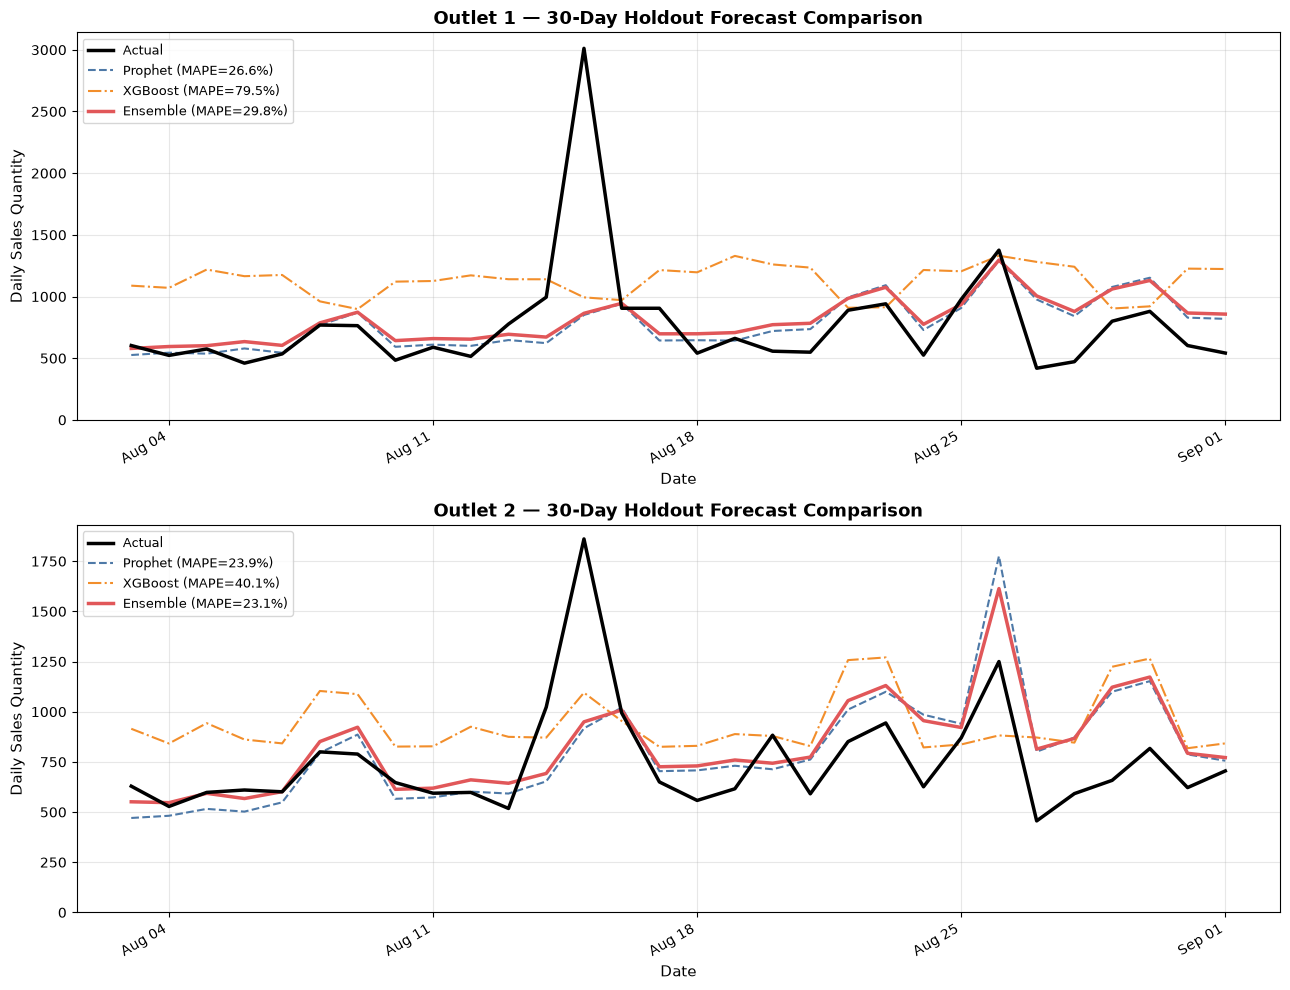

Chart saved: C:\Users\littl\Downloads\eris_project\research\notebooks\forecast_comparison.png


In [7]:
# Cell 7: Actual vs Predicted chart

model_styles = {
    'Prophet':  {'color': '#4e79a7', 'ls': '--',  'lw': 1.5},
    'XGBoost':  {'color': '#f28e2b', 'ls': '-.',  'lw': 1.5},
    'LSTM':     {'color': '#59a14f', 'ls': ':',   'lw': 1.5},
    'Ensemble': {'color': '#e15759', 'ls': '-',   'lw': 2.5},
}

fig, axes = plt.subplots(len(OUTLET_IDS), 1,
                          figsize=(13, 5*len(OUTLET_IDS)), sharex=False)
if len(OUTLET_IDS) == 1:
    axes = [axes]

for ax, oid in zip(axes, OUTLET_IDS):
    test_df = all_results[oid]['test_df']
    actuals = all_results[oid]['actuals']
    dates   = test_df['ds'].values

    ax.plot(dates, actuals, color='black', lw=2.5, label='Actual', zorder=5)

    for model_name, data in all_results[oid]['results'].items():
        preds = data['preds']
        m     = data['metrics']
        if np.all(np.isnan(preds)):
            continue
        s    = model_styles[model_name]
        lbl  = f"{m['MAPE (%)']: .1f}%" if not np.isnan(m['MAPE (%)']) else 'N/A'
        ax.plot(dates, preds, color=s['color'], ls=s['ls'], lw=s['lw'],
                label=f"{model_name} (MAPE={lbl.strip()})")

    ax.set_title(f'Outlet {oid} — 30-Day Holdout Forecast Comparison',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Daily Sales Quantity', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
chart_path = PROJECT_ROOT / 'research' / 'notebooks' / 'forecast_comparison.png'
plt.savefig(str(chart_path), dpi=120, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')

In [8]:
# Cell 8: Ensemble weight breakdown

print('Adaptive weights (inverse-error-weighted on validation MAPE)\n')
print(f'{"Outlet":<10} {"Prophet":<12} {"XGBoost":<12} {"LSTM":<12}')
print('-'*46)

for oid in OUTLET_IDS:
    res = all_results[oid]['results']
    m_p = res['Prophet']['metrics']['MAPE (%)']
    m_x = res['XGBoost']['metrics']['MAPE (%)']
    m_l = res['LSTM']['metrics']['MAPE (%)']
    w   = EnsembleForecaster().adaptive_weighting({
        'prophet': {'mape': m_p},
        'xgboost': {'mape': m_x},
        'lstm':    {'mape': None if np.isnan(m_l) else m_l},
    })
    print(f'Outlet {oid}   {w[0]:.3f}        {w[1]:.3f}        {w[2]:.3f}')

print('\nHigher weight = lower MAPE on validation split.')

Adaptive weights (inverse-error-weighted on validation MAPE)

Outlet     Prophet      XGBoost      LSTM        
----------------------------------------------
Outlet 1   0.749        0.251        0.000
Outlet 2   0.627        0.373        0.000

Higher weight = lower MAPE on validation split.
